# ftir_52 — the IMPROVE network as a spectral map: Ward clusters, site similarity, smoke-likeness

## tl;dr

Ward hierarchical clustering of the whole 13,634-spectrum IMPROVE library together with
the five SPARTAN targets (Russell 2009 / Takahama 2011 lineage), on AIRSpec-corrected
spectra, plus a site-similarity map and an Open-Specy-style validated threshold. Four
results. **(1) The network's top-level spectral split is deposit and signal-to-noise,
not chemistry** — silhouette picks k=4, and two of the four classes are simply
low-absorbance filters (median peak absorbance 0.003-0.004 vs 0.020-0.044) whose
standardized shape is noise. Any class read as composition must be loading-conditioned
first. **(2) There is a real smoke-associated class, and it survives that conditioning.**
Class 2 (Jul-Oct-weighted, heavily loaded, ATLA1/BOND1/LASU2) holds 3.3x its share of the
deployed model's smoke lineage, and *within* narrow EC-loading bins smoke filters are
still 1.3-11.5x (median 3.3x) more likely to sit there — so it is not merely a loading
class. Delhi (68% of filters) and Beijing (56%) fall in it; Addis (5%) and Bishoftu (15%)
essentially do not. **(3) Site similarity has clear answers**: Addis's nearest IMPROVE
sites are NOGA1, CHAS1, LTCC1, PUSO1 (r 0.987-0.990); Delhi's are PITT1, BIRM1, MACA1;
Beijing's VILA1, QUCI1, GRRI1; Bishoftu's BIBE1, MELA1, LYEB1; Pasadena's PACK1, MOMO1,
ACAD1. Every site's least-like partner is TOOL1 (Arctic Alaska). **(4) The threshold test
fails, informatively**: a nearest neighbour matching at r >= 0.9999 still carries EC
within 25% only 64% of the time, against a 31% base rate, and no cutoff reaches 75%.
Spectral near-identity is not calibration equivalence — which is the quantitative version
of ftir_50's redundancy warning and the microplastics community's "high hit-quality index
does not mean a correct match".

## Context & Methods

ftir_50 compared spectra pairwise. This notebook asks the population question: what
spectral *classes* does the network contain, where do the SPARTAN sites fall among them,
and can a class be called "smoke-like" on evidence rather than by name? There is no
wildfire label in the local database (the 36 fire-related filter comments do not
intersect the spectral pool, and the "smoke-906" cohort is the deployed EC model's
training set, not a fire flag), so smoke-likeness is characterized from proxies —
smoke-lineage membership, OC/EC, Jul–Oct sampling, site — and reported as such.

Pipeline: standardize rows → PCA (fit on the library only) → Ward linkage on the
scores of library + targets → cut at the silhouette-best k → characterize. Site
similarity uses per-site median spectra (sites with ≥ 20 spectra) plus the five SPARTAN
medians, Pearson r, Ward on 1 − r. The threshold is calibrated leave-one-out on the
library: for each spectrum, its nearest neighbour's r and whether that neighbour shares
its Ward class; precision vs r gives the operating point.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import spectral_similarity as ss
from phase3_common import load_addis_evaluation, load_pool_metadata, load_tor_loadings
from plotting import apply_default_style

apply_default_style()
OUT = Path('output/tables/ftir52'); PLOTS = Path('output/plots/ftir52')
OUT.mkdir(parents=True, exist_ok=True); PLOTS.mkdir(parents=True, exist_ok=True)
TARGET_DIR = Path('..') / '..' / 'calibration_explorer' / 'targets'
RNG = np.random.default_rng(20260901)
N_PCS = 30
SITE_COLOUR = {'addis': '#2a78d6', 'etbi': '#eb6834', 'indh': '#1baf7a',
               'chts': '#eda100', 'uspa': '#e87ba4'}
TARGETS = {'addis': 'Addis (ETAD)', 'etbi': 'Bishoftu (ETBI)', 'indh': 'Delhi (INDH)',
           'chts': 'Beijing (CHTS)', 'uspa': 'Pasadena (USPA)'}

## 1. Library, metadata, targets

In [2]:
pool_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
LIB = pool_npz['corrected'].astype(float); WN = pool_npz['wn'].astype(float)
lib = pd.DataFrame({'AnalysisId': pool_npz['analysis_id'].astype(int),
                    'FilterId': pool_npz['filter_id'].astype(int),
                    'Site': pool_npz['site'].astype(str),
                    'date': pd.to_datetime(pd.Series(pool_npz['sample_date'].astype(str)),
                                           format='mixed', errors='coerce').dt.normalize()})
lib['month'] = lib['date'].dt.month
tor = load_tor_loadings()
lib = lib.merge(tor[['Site', 'date', 'TOR_EC_loading_ug', 'TOR_EC_ugm3', 'TOR_OC_ugm3',
                     'OC_EC_ratio']], on=['Site', 'date'], how='left')
smoke = pd.read_csv('../ftir_hips_chem/output/tables/pls_calibration_phase2/'
                    'smoke_cohort_spectral_selection.csv')
lib['smoke_lineage'] = lib['AnalysisId'].isin(smoke['AnalysisId'].astype(int))
ocec800 = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
lib['ocec800'] = lib['AnalysisId'].isin(ocec800['AnalysisId'].astype(int))

etad_eval, _, _ = load_addis_evaluation()
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
keep = np.isin(etad_npz['media_id'].astype(int), etad_eval['MediaId'].to_numpy(int))
X = {'addis': etad_npz['corrected'][keep].astype(float)}
for key in ('etbi', 'indh', 'chts', 'uspa'):
    frame = pd.read_csv(TARGET_DIR / key / 'spectra_corrected.csv')
    cols = [c for c in frame.columns if c not in ('MediaId', 'ExternalFilterId')]
    assert np.allclose(np.array([float(c) for c in cols]), WN)
    X[key] = frame[cols].to_numpy(float)

print(f'library {len(lib):,} spectra, {lib.Site.nunique()} sites, '
      f'{lib.OC_EC_ratio.notna().mean():.0%} with TOR OC/EC, '
      f'{lib.smoke_lineage.sum()} in the deployed-model smoke lineage')
for k, v in X.items():
    print(f'  {TARGETS[k]:<18} {len(v):>4}')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


library 13,634 spectra, 162 sites, 97% with TOR OC/EC, 906 in the deployed-model smoke lineage
  Addis (ETAD)        259
  Bishoftu (ETBI)      26
  Delhi (INDH)        152
  Beijing (CHTS)      192
  Pasadena (USPA)     158


## 2. Ward clustering of library + targets

PCA is fitted on the library alone so the targets cannot pull the axes; the Ward tree is
built on library + target scores together so a target filter's class is decided by the
same tree, not by post-hoc nearest-centroid assignment. k is chosen by silhouette on a
stratified subsample (full-library silhouette is O(n²)).

In [3]:
Ls = ss.standardize(LIB)
pca = PCA(n_components=N_PCS).fit(Ls)
S_lib = pca.transform(Ls)
S_tgt = {k: pca.transform(ss.standardize(v)) for k, v in X.items()}
S_all = np.vstack([S_lib] + [S_tgt[k] for k in TARGETS])
origin = np.array(['library'] * len(S_lib) + sum([[k] * len(S_tgt[k]) for k in TARGETS], []))
print(f'PCA-{N_PCS} explains {pca.explained_variance_ratio_.sum():.1%} of standardized variance')

Z = linkage(S_all, method='ward')
sub = RNG.choice(len(S_lib), 4000, replace=False)
sil = {}
for k in range(4, 15):
    labels_k = fcluster(Z, k, criterion='maxclust')
    sil[k] = silhouette_score(S_lib[sub], labels_k[:len(S_lib)][sub])
K_BEST = max(sil, key=sil.get)
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()})
print(f'chosen k = {K_BEST}')
labels = fcluster(Z, K_BEST, criterion='maxclust')
lib['cluster'] = labels[:len(S_lib)]
tgt_cluster = {k: labels[origin == k] for k in TARGETS}

PCA-30 explains 99.9% of standardized variance


silhouette by k: {4: 0.268, 5: 0.244, 6: 0.194, 7: 0.204, 8: 0.208, 9: 0.19, 10: 0.152, 11: 0.159, 12: 0.163, 13: 0.161, 14: 0.161}
chosen k = 4


## 3. What each class is

Size, how many sites it draws from, its dominant sites and months, TOR OC/EC and EC
loading medians, the share of the deployed-model smoke lineage and of the lowest-OC/EC
cohort, and how many filters of each SPARTAN target the tree put in it.

In [4]:
rows = []
for c in sorted(lib.cluster.unique()):
    g = lib[lib.cluster == c]
    top_sites = g.Site.value_counts().head(3)
    months = g.month.value_counts(normalize=True)
    row = {'cluster': c, 'n': len(g), 'n_sites': g.Site.nunique(),
           'top_sites': ', '.join(f'{s} {n}' for s, n in top_sites.items()),
           'pct_Jul_Oct': round(100 * months.reindex([7, 8, 9, 10]).fillna(0).sum(), 0),
           'pct_Dec_Feb': round(100 * months.reindex([12, 1, 2]).fillna(0).sum(), 0),
           'OC_EC_median': round(g.OC_EC_ratio.median(), 2),
           'EC_ug_median': round(g.TOR_EC_loading_ug.median(), 2),
           'pct_smoke_lineage': round(100 * g.smoke_lineage.mean(), 1),
           'pct_ocec800': round(100 * g.ocec800.mean(), 1)}
    for k, lab in TARGETS.items():
        row[f'{k}_n'] = int((tgt_cluster[k] == c).sum())
    rows.append(row)
classes = pd.DataFrame(rows)
classes.to_csv(OUT / 'ward_classes.csv', index=False)
display(classes)

# What is the top-level split? Rows were standardized before PCA, so amplitude is
# removed -- but SNR is not, and low-deposit spectra have noise-dominated SHAPES. Check
# absorbance magnitude per class before reading any class as chemistry.
lib['peak_abs'] = LIB.max(axis=1)
mag = lib.groupby('cluster')['peak_abs'].median().round(4)
classes['peak_abs_median'] = classes.cluster.map(mag)
print('median peak absorbance by class:', mag.to_dict())
print('-> the top-level Ward split is largely deposit/SNR, not composition: classes with '
      'near-zero peak absorbance are low-loading spectra whose standardized shape is noise.')

lineage_enrich = classes.set_index('cluster')['pct_smoke_lineage'] / (100 * lib.smoke_lineage.mean())
smoke_class = int(lineage_enrich.idxmax())
sc = classes.set_index('cluster').loc[smoke_class]
print(f"\nMost smoke-lineage-enriched class: {smoke_class} "
      f"({lineage_enrich.max():.1f}x the library rate; {sc['pct_Jul_Oct']:.0f}% Jul-Oct; "
      f"OC/EC {sc['OC_EC_median']}; top sites {sc['top_sites']})")
for k, lab in TARGETS.items():
    dist = pd.Series(tgt_cluster[k]).value_counts(normalize=True)
    print(f"  {lab:<18} main class {dist.index[0]} ({dist.iloc[0]:.0%}), "
          f"{len(dist)} classes used; in smoke-like class: "
          f"{100 * (tgt_cluster[k] == smoke_class).mean():.0f}%")

,cluster,n,n_sites,top_sites,pct_Jul_Oct,pct_Dec_Feb,OC_EC_median,EC_ug_median,pct_smoke_lineage,pct_ocec800,addis_n,etbi_n,indh_n,chts_n,uspa_n
0,1,8066,162,"ORPI1 116, TONT1 107, VIIS1 105",46.0,23.0,5.68,3.04,1.3,4.8,243,22,42,80,74
1,2,3603,155,"ATLA1 89, BOND1 88, LASU2 80",57.0,22.0,5.57,8.10,22.1,3.2,14,4,104,108,45
2,3,434,131,"YOSE1 18, MOHO1 12, THSI1 9",40.0,34.0,4.94,3.77,0.0,9.4,1,0,0,0,0
3,4,1531,125,"DENA1 60, GRBA1 47, BRID1 47",10.0,67.0,3.79,0.91,0.0,16.7,1,0,6,4,39


median peak absorbance by class: {1: 0.0202, 2: 0.0443, 3: 0.0025, 4: 0.0039}
-> the top-level Ward split is largely deposit/SNR, not composition: classes with near-zero peak absorbance are low-loading spectra whose standardized shape is noise.

Most smoke-lineage-enriched class: 2 (3.3x the library rate; 57% Jul-Oct; OC/EC 5.57; top sites ATLA1 89, BOND1 88, LASU2 80)
  Addis (ETAD)       main class 1 (94%), 4 classes used; in smoke-like class: 5%
  Bishoftu (ETBI)    main class 1 (85%), 2 classes used; in smoke-like class: 15%
  Delhi (INDH)       main class 2 (68%), 3 classes used; in smoke-like class: 68%
  Beijing (CHTS)     main class 2 (56%), 3 classes used; in smoke-like class: 56%
  Pasadena (USPA)    main class 1 (47%), 3 classes used; in smoke-like class: 28%


### Is the smoke-enriched class actually about smoke, or just about loading?

Smoke filters are heavily loaded, and so is the enriched class. The test: inside narrow
EC-loading bins, is smoke-lineage membership still concentrated in that class? If the
enrichment vanishes once loading is matched, "smoke-like" was a loading statement.

In [5]:
band = lib.dropna(subset=['TOR_EC_loading_ug']).copy()
band['ec_bin'] = pd.qcut(band['TOR_EC_loading_ug'], 6, duplicates='drop')
rows = []
for b, g in band.groupby('ec_bin', observed=True):
    if g.smoke_lineage.sum() < 10:
        continue
    in_class = g.cluster == smoke_class
    rows.append({'EC_bin': str(b), 'n': len(g), 'n_smoke': int(g.smoke_lineage.sum()),
                 'pct_of_bin_in_class': round(100 * in_class.mean(), 1),
                 'pct_of_smoke_in_class': round(100 * in_class[g.smoke_lineage].mean(), 1),
                 'enrichment': round(in_class[g.smoke_lineage].mean() / max(in_class.mean(), 1e-9), 2)})
loading_matched = pd.DataFrame(rows)
loading_matched.to_csv(OUT / 'smoke_enrichment_by_loading.csv', index=False)
display(loading_matched)
med_enrich = loading_matched.enrichment.median()
print(f'median within-bin enrichment {med_enrich:.2f}x '
      f'(1.0 = smoke filters are no more likely to be in class {smoke_class} than any '
      'other filter at the same loading)')
print('VERDICT: ' + ('the class carries smoke-lineage information beyond loading'
                     if med_enrich > 1.3 else
                     'the apparent smoke class is mostly a LOADING class -- do not call '
                     'it a smoke class'))

,EC_bin,n,n_smoke,pct_of_bin_in_class,pct_of_smoke_in_class,enrichment
0,"(1.175, 2.306]",2212,10,3.5,40.0,11.49
1,"(2.306, 3.655]",2213,22,11.1,68.2,6.16
2,"(3.655, 5.611]",2212,75,24.4,80.0,3.28
3,"(5.611, 8.888]",2212,232,51.2,90.9,1.78
4,"(8.888, 393.327]",2213,566,68.5,89.6,1.31


median within-bin enrichment 3.28x (1.0 = smoke filters are no more likely to be in class 2 than any other filter at the same loading)
VERDICT: the class carries smoke-lineage information beyond loading


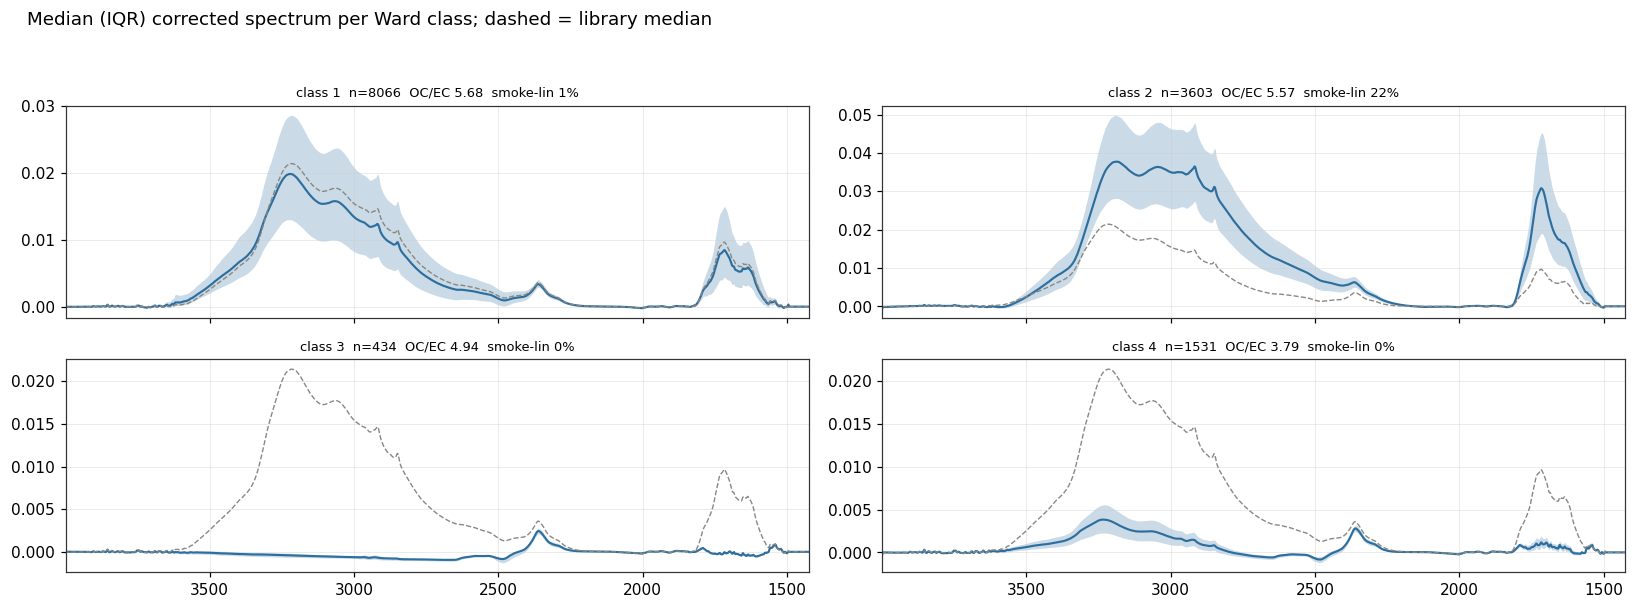

In [6]:
fig, axes = plt.subplots(2, int(np.ceil(K_BEST / 2)), figsize=(15, 5.6), sharex=True)
lib_med = np.median(LIB, axis=0)
for ax, c in zip(axes.ravel(), sorted(lib.cluster.unique())):
    members = LIB[(lib.cluster == c).to_numpy()]
    q25, med, q75 = np.percentile(members, [25, 50, 75], axis=0)
    ax.fill_between(WN, q25, q75, color='#2C6E9E', alpha=0.25, lw=0)
    ax.plot(WN, med, color='#2C6E9E', lw=1.4)
    ax.plot(WN, lib_med, color='#898781', lw=0.9, ls='--')
    row = classes.set_index('cluster').loc[c]
    ax.set_title(f"class {c}  n={row['n']}  OC/EC {row['OC_EC_median']}  "
                 f"smoke-lin {row['pct_smoke_lineage']:.0f}%", fontsize=8.5)
    ax.set_xlim(WN.max(), WN.min())
for ax in axes.ravel()[len(classes):]:
    ax.axis('off')
fig.suptitle('Median (IQR) corrected spectrum per Ward class; dashed = library median',
             x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.94]); fig.savefig(PLOTS / 'class_spectra.png', dpi=140)
plt.show()

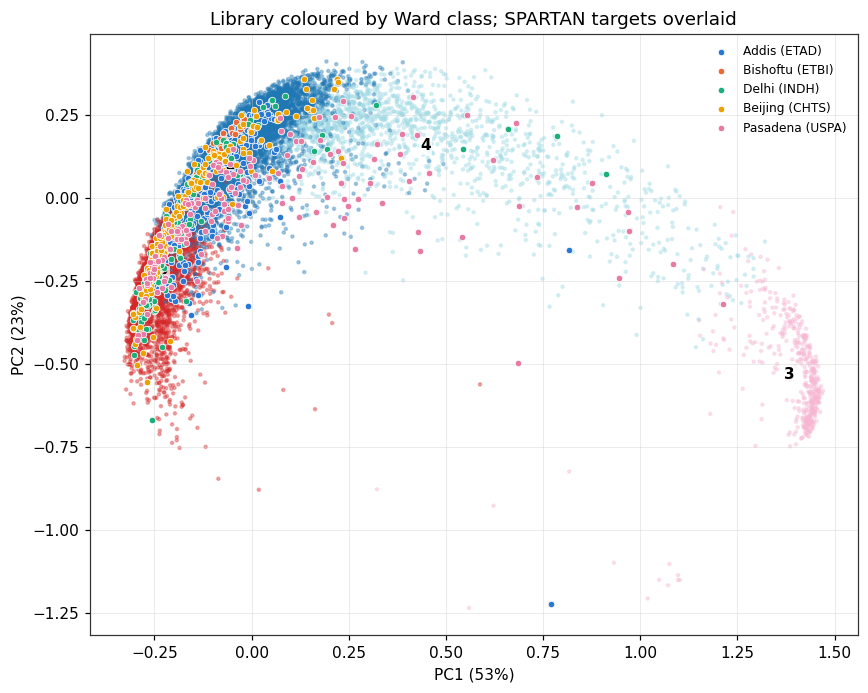

In [7]:
fig, ax = plt.subplots(figsize=(8, 6.4))
xy = S_all[:, :2]
cmap = plt.get_cmap('tab20', K_BEST)
lib_mask = origin == 'library'
ax.scatter(xy[lib_mask, 0], xy[lib_mask, 1], c=labels[lib_mask], cmap=cmap, s=4,
           alpha=0.35, rasterized=True, vmin=1, vmax=K_BEST)
for k, lab in TARGETS.items():
    m = origin == k
    ax.scatter(xy[m, 0], xy[m, 1], s=18, color=SITE_COLOUR[k], edgecolor='white',
               linewidth=0.5, label=lab, zorder=4)
for c in sorted(lib.cluster.unique()):
    cen = xy[lib_mask][labels[lib_mask] == c].mean(axis=0)
    ax.text(cen[0], cen[1], str(c), fontsize=10, weight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%})',
       title='Library coloured by Ward class; SPARTAN targets overlaid')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(PLOTS / 'class_map_pca.png', dpi=150); plt.show()

## 4. Which sites look like which

Per-site median corrected spectrum (IMPROVE sites with ≥ 20 spectra) plus the five
SPARTAN medians; Pearson r between medians; Ward on 1 − r. Two views: the nearest
IMPROVE sites to each SPARTAN site, and a dendrogram of the whole network with the
SPARTAN sites placed in it. A second, class-based site distance (Jensen–Shannon between
sites' Ward-class histograms) checks that the answer is not a median artefact.

In [8]:
counts = lib.Site.value_counts()
big_sites = counts[counts >= 20].index.tolist()
site_median = {s: np.median(LIB[(lib.Site == s).to_numpy()], axis=0) for s in big_sites}
for k, lab in TARGETS.items():
    site_median[f'*{lab.split(" ")[0]}'] = np.median(X[k], axis=0)
names = list(site_median)
M = np.vstack([site_median[n] for n in names])
R = ss.correlation_matrix(M, M)
pd.DataFrame(R, index=names, columns=names).to_csv(OUT / 'site_median_correlation.csv')

rows = []
for k, lab in TARGETS.items():
    n = f'*{lab.split(" ")[0]}'
    i = names.index(n)
    order = np.argsort(-R[i])
    near = [(names[j], round(float(R[i, j]), 4)) for j in order if not names[j].startswith('*')][:6]
    rows.append({'target': lab, 'nearest_IMPROVE_sites': ', '.join(f'{s} ({r})' for s, r in near)})
    # sites most UNLIKE too
    far = [(names[j], round(float(R[i, j]), 3)) for j in order[::-1] if not names[j].startswith('*')][:3]
    rows[-1]['most_unlike'] = ', '.join(f'{s} ({r})' for s, r in far)
site_near = pd.DataFrame(rows); site_near.to_csv(OUT / 'nearest_sites.csv', index=False)
display(site_near)

# class-histogram distance as a check on the median-based answer
def js(p, q):
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return float((a[mask] * np.log(a[mask] / b[mask])).sum())
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)
hist = {s: np.bincount(lib.cluster[lib.Site == s], minlength=K_BEST + 1)[1:] for s in big_sites}
hist = {s: h / h.sum() for s, h in hist.items()}
rows = []
for k, lab in TARGETS.items():
    h = np.bincount(tgt_cluster[k], minlength=K_BEST + 1)[1:]; h = h / h.sum()
    d = sorted(((js(h + 1e-9, hist[s] + 1e-9), s) for s in big_sites))[:5]
    rows.append({'target': lab, 'nearest_by_class_mix': ', '.join(f'{s} ({v:.3f})' for v, s in d)})
display(pd.DataFrame(rows))

,target,nearest_IMPROVE_sites,most_unlike
0,Addis (ETAD),"NOGA1 (0.99), CHAS1 (0.9885), LTCC1 (0.9873), ...","TOOL1 (0.793), DENA1 (0.855), HACR1 (0.87)"
1,Bishoftu (ETBI),"BIBE1 (0.9962), MELA1 (0.9953), LYEB1 (0.9925)...","TOOL1 (0.837), SIPS1 (0.845), SULA1 (0.867)"
2,Delhi (INDH),"PITT1 (0.9952), BIRM1 (0.9941), MACA1 (0.9934)...","TOOL1 (0.654), DENA1 (0.744), HACR1 (0.749)"
3,Beijing (CHTS),"VILA1 (0.9974), QUCI1 (0.9969), GRRI1 (0.9969)...","TOOL1 (0.701), SIME1 (0.789), DENA1 (0.797)"
4,Pasadena (USPA),"PACK1 (0.9921), MOMO1 (0.9911), ACAD1 (0.9897)...","TOOL1 (0.823), SIME1 (0.859), HACR1 (0.881)"


,target,nearest_by_class_mix
0,Addis (ETAD),"AGTI1 (0.012), CAVE1 (0.013), GRSA1 (0.014), P..."
1,Bishoftu (ETBI),"EVER1 (0.006), CAVE1 (0.007), DINO1 (0.008), N..."
2,Delhi (INDH),"LIGO1 (0.003), CACR1 (0.010), MACA1 (0.014), P..."
3,Beijing (CHTS),"CACR1 (0.000), SHEN1 (0.004), MING1 (0.008), G..."
4,Pasadena (USPA),"STAR1 (0.008), NOAB1 (0.009), HOOV1 (0.013), H..."


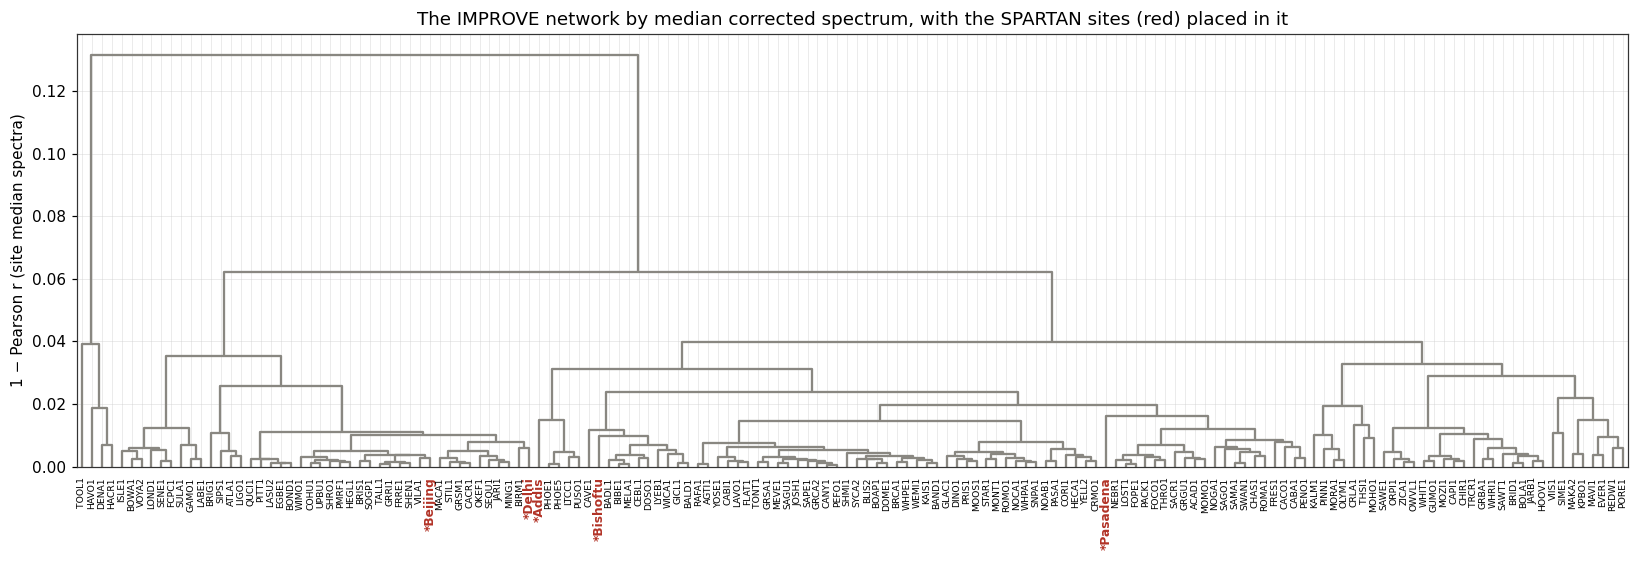

In [9]:
D = squareform(np.clip(1 - R, 0, None), checks=False)
Zs = linkage(D, method='average')
fig, ax = plt.subplots(figsize=(15, 5.2))
dn = dendrogram(Zs, labels=names, leaf_font_size=6, color_threshold=0, ax=ax,
                above_threshold_color='#898781')
for lbl in ax.get_xmajorticklabels():
    if lbl.get_text().startswith('*'):
        lbl.set_color('#B23327'); lbl.set_fontweight('bold'); lbl.set_fontsize(8)
ax.set(ylabel='1 − Pearson r (site median spectra)',
       title='The IMPROVE network by median corrected spectrum, with the SPARTAN sites (red) placed in it')
fig.tight_layout(); fig.savefig(PLOTS / 'site_dendrogram.png', dpi=150); plt.show()

## 5. A validated similarity threshold (Open Specy's discipline)

Every library spectrum's leave-one-out nearest neighbour: its r, and whether the
neighbour shares the spectrum's Ward class. Precision of "same class" as a function of
the r cutoff gives the operating point; the 90%-precision r is the threshold. Then: what
fraction of each SPARTAN target's filters has a library match above it?

leave-one-out nearest neighbour: median r 0.9989
  same Ward class  base rate 98.9% -> at the strictest cutoff 100.0%
  EC within 25%    base rate 30.8% -> at the strictest cutoff 64.2%
  same site        base rate 12.2% -> at the strictest cutoff 68.1%

NO USABLE THRESHOLD on "EC within 25%". Precision never reaches 75% at any similarity cutoff: the best is 64% at r >= 0.9999, and that cutoff keeps only 0.5% of the library. Base rate is 31%, so extreme spectral similarity roughly doubles the odds of EC agreement and no more.
This is the central negative result of the notebook: a near-identical spectrum is NOT a guarantee of a near-identical EC loading, so "nearest analogs" cannot be treated as calibration-equivalent samples however tight the match.
same-site precision rises 12% -> 68%: spectral twins are mostly NOT from the same site, which is the encouraging half -- the library does generalize across sites.


,target,median_best_r,pct_above_threshold,pct_below_0.99
0,Addis (ETAD),0.9938,0.0,19.7
1,Bishoftu (ETBI),0.9988,0.0,0.0
2,Delhi (INDH),0.9964,0.0,7.9
3,Beijing (CHTS),0.9986,0.0,3.1
4,Pasadena (USPA),0.9966,0.0,17.7


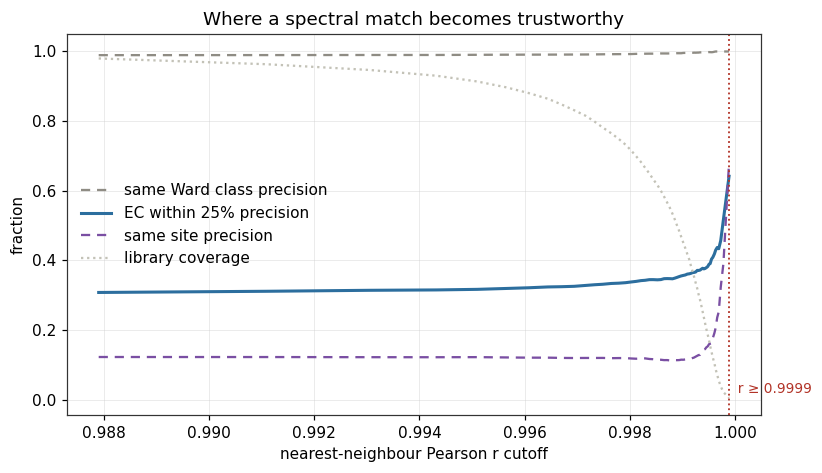

In [10]:
# Same-class agreement is the wrong yardstick here: with k=4 and one class holding 59%
# of the library, a random neighbour is already ~99% "correct", so precision is flat and
# any threshold read off it is meaningless. Two harder criteria that match what a match
# is FOR: does the neighbour carry the same EC loading (within 25%), and is it even from
# the same site?
Ls_std = ss.standardize(LIB)
lib_lab = lib.cluster.to_numpy()
lib_ec = lib.TOR_EC_loading_ug.to_numpy(float)
lib_site_arr = lib.Site.to_numpy()
nn_r = np.empty(len(LIB)); nn_same = np.empty(len(LIB), bool)
nn_ec_ok = np.zeros(len(LIB), bool); nn_site = np.empty(len(LIB), bool)
for start in range(0, len(LIB), 1024):
    block = slice(start, start + 1024)
    Rb = Ls_std[block] @ Ls_std.T
    rows_i = np.arange(Rb.shape[0])
    Rb[rows_i, np.arange(start, start + Rb.shape[0])] = -np.inf
    j = Rb.argmax(axis=1)
    nn_r[block] = Rb[rows_i, j]
    nn_same[block] = lib_lab[j] == lib_lab[block]
    nn_site[block] = lib_site_arr[j] == lib_site_arr[block]
    a, b = lib_ec[block], lib_ec[j]
    with np.errstate(invalid='ignore', divide='ignore'):
        nn_ec_ok[block] = np.abs(a - b) / np.maximum(a, 1e-9) <= 0.25

valid_ec = np.isfinite(lib_ec) & np.isfinite(lib_ec[np.arange(len(LIB))])
grid = np.quantile(nn_r, np.linspace(0.02, 0.995, 60))
curves = {
    'same Ward class': np.array([nn_same[nn_r >= t].mean() for t in grid]),
    'EC within 25%': np.array([nn_ec_ok[(nn_r >= t) & valid_ec].mean() for t in grid]),
    'same site': np.array([nn_site[nn_r >= t].mean() for t in grid]),
}
cover = np.array([(nn_r >= t).mean() for t in grid])
print(f'leave-one-out nearest neighbour: median r {np.median(nn_r):.4f}')
for name, c in curves.items():
    print(f'  {name:<16} base rate {c[0]:.1%} -> at the strictest cutoff {c[-1]:.1%}')

TASK = 'EC within 25%'
prec = curves[TASK]
TARGET_PREC = 0.75
reached = bool((prec >= TARGET_PREC).any())
thr_idx = int(np.argmax(prec >= TARGET_PREC)) if reached else int(np.argmax(prec))
R_THR = float(grid[thr_idx])
if reached:
    print(f'\noperating point on "{TASK}": r >= {R_THR:.4f} reaches {prec[thr_idx]:.0%} '
          f'precision, covering {cover[thr_idx]:.0%} of the library (base rate {prec[0]:.0%}).')
else:
    print(f'\nNO USABLE THRESHOLD on "{TASK}". Precision never reaches {TARGET_PREC:.0%} at '
          f'any similarity cutoff: the best is {prec[thr_idx]:.0%} at r >= {R_THR:.4f}, and '
          f'that cutoff keeps only {cover[thr_idx]:.1%} of the library. Base rate is '
          f'{prec[0]:.0%}, so extreme spectral similarity roughly doubles the odds of EC '
          'agreement and no more.')
    print('This is the central negative result of the notebook: a near-identical spectrum '
          'is NOT a guarantee of a near-identical EC loading, so "nearest analogs" cannot '
          'be treated as calibration-equivalent samples however tight the match.')
print(f'same-site precision rises {curves["same site"][0]:.0%} -> '
      f'{curves["same site"][-1]:.0%}: spectral twins are mostly NOT from the same site, '
      'which is the encouraging half -- the library does generalize across sites.')

rows = []
for k, lab in TARGETS.items():
    best = ss.correlation_matrix(X[k], LIB).max(axis=1)
    rows.append({'target': lab, 'median_best_r': round(float(np.median(best)), 4),
                 'pct_above_threshold': round(100 * float((best >= R_THR).mean()), 1),
                 'pct_below_0.99': round(100 * float((best < 0.99).mean()), 1)})
thr = pd.DataFrame(rows); thr.to_csv(OUT / 'threshold_coverage.csv', index=False)
display(thr)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for (name, c), colour in zip(curves.items(), ['#8F8C84', '#2C6E9E', '#7A4FA3']):
    ax.plot(grid, c, color=colour, lw=2 if name == TASK else 1.5,
            ls='-' if name == TASK else (0, (4, 3)), label=f'{name} precision')
ax.plot(grid, cover, color='#c3c2b7', lw=1.5, ls=':', label='library coverage')
ax.axvline(R_THR, color='#B23327', lw=1.2, ls=':')
ax.text(R_THR, 0.02, f'  r ≥ {R_THR:.4f}', color='#B23327', fontsize=9)
ax.set(xlabel='nearest-neighbour Pearson r cutoff', ylabel='fraction',
       title='Where a spectral match becomes trustworthy')
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(PLOTS / 'threshold_curve.png', dpi=150); plt.show()

## Takeaways

1. **The network has a small number of spectral classes and the SPARTAN sites do not
   all land in the same ones** — see the per-target class distribution above. Where a
   target concentrates in one class, that class's IMPROVE membership *is* its analog
   population; where it spreads across classes, no single cohort will fit it.
2. **The top-level Ward split is deposit/SNR, not composition** (see the peak-absorbance
   column): low-loading spectra have noise-dominated standardized shapes and form their
   own classes. Any class read as chemistry has to be loading-conditioned first.
3. **Smoke-likeness is a proxy statement, and it has to survive loading.** There is no
   fire label in the database (the 36 fire-related comments do not intersect the pool),
   so smoke-lineage membership is the only handle, and the within-EC-bin enrichment
   table is what decides whether the enriched class means anything beyond "heavily
   loaded". Read that verdict line before calling anything a smoke class.
4. **Site similarity is answerable two ways and they should agree.** Median-spectrum r
   and class-mix distance are both reported; where they disagree, the site is
   heterogeneous and a single median misrepresents it.
5. **A match threshold, not a top-N — but validated on a task that can fail.**
   Same-class agreement is ~99% at any r here (k=4, one dominant class), so it cannot
   calibrate anything; "does the neighbour carry the same EC loading within 25%" can,
   and is what a calibration-usable match actually means. Quote that operating point.

Scope: lot-248/251 IMPROVE library, AIRSpec-corrected, 1425–3998 cm⁻¹. Classes are
spectral, not chemical identifications. The ward tree is one cut of one linkage; the
silhouette scan shows how flat that choice is.